# Week 5 Advanced Machine Learning
**AnalystLab Africa Internship**

The goal of this week is not just to build a model but to compare different algorithms and identify the best performing solution for the given problem

## Step 1: Data Preparations

## Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

## Load Dataset

In [2]:
titanic_df=pd.read_csv('Titanic-Cleaned.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",-0.565736,1,0,A/5 21171,-0.700836,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.663861,1,0,PC 17599,1.491434,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",-0.258337,0,0,STON/O2. 3101282,-0.677726,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.433312,1,0,113803,0.868903,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0.433312,0,0,373450,-0.673447,True,False,True


## Explore the dataset

In [3]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    str    
 8   Fare         891 non-null    float64
 9   Sex_male     891 non-null    bool   
 10  Embarked_Q   891 non-null    bool   
 11  Embarked_S   891 non-null    bool   
dtypes: bool(3), float64(2), int64(5), str(2)
memory usage: 65.4 KB


In [4]:
print("Missing values per column:\n", titanic_df.isnull().sum())
print("\nDuplicated rows", titanic_df.duplicated().sum())

Missing values per column:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Sex_male       0
Embarked_Q     0
Embarked_S     0
dtype: int64

Duplicated rows 0


## Split dataset into training and testing

In [5]:
#select features 
features=['Fare','Age','Pclass','Sex_male']
X=titanic_df[features]
Y=titanic_df['Survived']


X_train,X_test,Y_train,Y_test=train_test_split(X,Y, test_size=0.2, random_state=42)
print(f"Training set:{X_train.shape[0]} rows")
print(f"Testing set:{X_test.shape[0]} rows")


Training set:712 rows
Testing set:179 rows


## Step 2:Build a Decision Tree Model
A Decision Tree is a non-parametric supervised learning algorithm used for both classification (predicting discrete labels) and regression (predicting continuous values).
It works by recursively splitting dataset features into subsets based on simple, sequential decision rules.

In [6]:
tree_model=DecisionTreeClassifier(criterion='gini',
                                 max_depth=5,
                                 min_samples_split=10)

## Perform  training and make predictions

In [7]:
tree_model.fit(X_train,Y_train)
y_pred=tree_model.predict(X_test)
results=pd.DataFrame({'Actual':Y_test.values, 'Predicted':y_pred})
results.head(10)

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,1
4,1,0
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


## Model evaluation

Accuracy:81.56%

Classification Report
                 precision    recall  f1-score   support

       Survived       0.81      0.90      0.85       105
Did not Survive       0.84      0.69      0.76        74

       accuracy                           0.82       179
      macro avg       0.82      0.80      0.80       179
   weighted avg       0.82      0.82      0.81       179



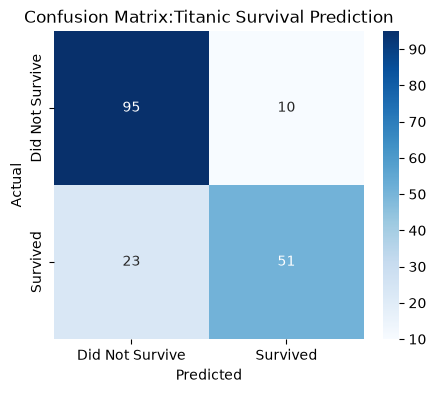

In [8]:
acc=accuracy_score(Y_test,y_pred)
print(f"Accuracy:{acc:.2%}\n")
print("Classification Report")
print(classification_report(Y_test,y_pred,target_names=['Survived','Did not Survive']))
cm=confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive','Survived'],
            yticklabels=['Did Not Survive','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix:Titanic Survival Prediction')
plt.show()

## Step 3:Build a Random Forest Model
A Random Forest is an ensemble learning method that combines the predictions of dozens or hundreds of individual decision trees to build a more robust and accurate model.
While a single decision tree is prone to high variance and overestimates noise in training data, Random Forests fix this by training diverse trees on different subsets of the data and averaging their outputs.


In [9]:
rf=RandomForestClassifier(n_estimators=100,      # Number of trees in the forest
    max_features='sqrt',   # Features considered per split
    max_depth=10,          # Depth control for individual trees
    oob_score=True,        # Use out-of-bag samples for validation
    random_state=42,
    n_jobs=-1              # Use all CPU cores for parallel training)
                         )

## Perfoming Training and Predictions


In [11]:
rf.fit(X_train,Y_train)
y_pred=rf.predict(X_test)
results=pd.DataFrame({'Actual':Y_test.values, 'Predicted':y_pred})
results.head(10)


,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,1
4,1,0
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


## Evaluate the Random Forest Model

Accuracy:81.56%

Classification report
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.90      0.85       105
       Survived       0.83      0.70      0.76        74

       accuracy                           0.82       179
      macro avg       0.82      0.80      0.80       179
   weighted avg       0.82      0.82      0.81       179



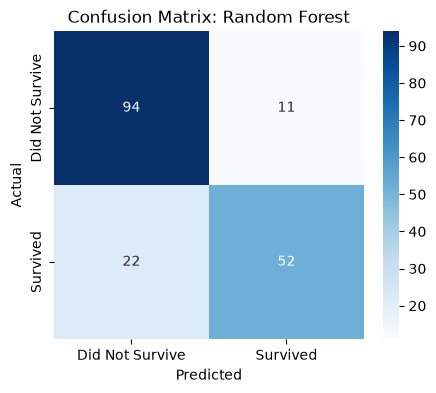


Out-of-Bag Score: 83.15%


In [14]:
rf_acc=accuracy_score(Y_test, y_pred)
print(f"Accuracy:{rf_acc:.2%}\n")
print("Classification report")
print(classification_report(Y_test, y_pred, target_names=['Did Not Survive','Survived']))
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive','Survived'],
            yticklabels=['Did Not Survive','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Random Forest')
plt.show()

print(f"\nOut-of-Bag Score: {rf.oob_score_:.2%}")


**Comparison to the Decision Tree**:the Random Forest generally reduces variance by averaging many trees, so we expect it to generalise at least as well

## Step 4:Build a Gradient Boosting Model
Gradient Boosting builds trees **sequentially**, where each new tree tries to correct the errors made by the previous ones, rather than training many independent trees in parallel like Random Forest. This often improves accuracy further but can be more prone to overfitting if not tuned carefully.

Classification Report
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.90      0.86       105
       Survived       0.83      0.73      0.78        74

       accuracy                           0.83       179
      macro avg       0.83      0.81      0.82       179
   weighted avg       0.83      0.83      0.82       179



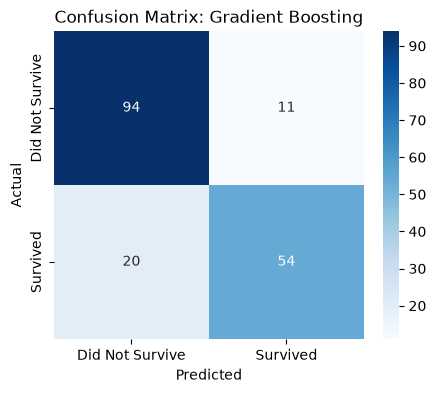

In [21]:
gb=GradientBoostingClassifier(n_estimators=100,
                              learning_rate=0.1,
                              max_depth=3,
                              random_state=42
                             )
gb.fit(X_train,Y_train)
y_pred_gb=gb.predict(X_test)
gb_acc=accuracy_score(Y_test,y_pred_gb)
print("Classification Report")
print(classification_report(Y_test, y_pred_gb, target_names=['Did Not Survive','Survived']))

cm = confusion_matrix(Y_test, y_pred_gb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive','Survived'],
            yticklabels=['Did Not Survive','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Gradient Boosting')
plt.show()